In [1]:
import sys
import os
if os.path.abspath('..') not in sys.path:
    sys.path.append(os.path.abspath('..'))

from matplotlib import pyplot as plt
import conquer3d as c3d

import torch
import tqdm
import numpy as np
import kaolin as kal
import render
import open3d as o3d
import util
import nvdiffrast.torch as dr


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
iter = 1000
batch = 8
train_res = [2048, 2048]
learning_rate = 0.01
voxel_grid_res = 64
device = 'cuda'

glctx = dr.RasterizeCudaContext(device=device)


In [3]:
mesh = o3d.io.read_triangle_mesh(o3d.data.BunnyMesh().path)

print("# vertices:", len(mesh.vertices))
print("# triangles:", len(mesh.triangles))

print(type(mesh))


# vertices: 35947
# triangles: 69451
<class 'open3d.cuda.pybind.geometry.TriangleMesh'>


In [4]:
# Make front face towards +Z
R = mesh.get_rotation_matrix_from_xyz((0, np.pi, 0))
mesh.rotate(R, center=(0, 0, 0))


TriangleMesh with 35947 points and 69451 triangles.

In [5]:
vertices = np.asarray(mesh.vertices).astype(np.float32)
triangles = np.asarray(mesh.triangles).astype(np.int64)

print(f"vertices: {vertices.shape}, triangles: {triangles.shape}")
print(f"vertices: {vertices.dtype}, triangles: {triangles.dtype}")
print(f"vertices min: {vertices.min()}, \nvertices max: {vertices.max()}")


vertices: (35947, 3), triangles: (69451, 3)
vertices: float32, triangles: int64
vertices min: -0.06100910156965256, 
vertices max: 0.1873210072517395


In [6]:
vertices = torch.from_numpy(vertices).float()
triangles = torch.from_numpy(triangles).long()

vmin, vmax = vertices.min(dim=0)[0], vertices.max(dim=0)[0]
scale = 1.8 / torch.max(vmax - vmin).item()

vertices = vertices - (vmax + vmin) / 2
vertices = vertices * scale

print(f"vertices min: {vertices.min()}, \nvertices max: {vertices.max()}")
print(f"vertices: {vertices.shape}, triangles: {triangles.shape}")


vertices min: -0.9000000357627869, 
vertices max: 0.9000000357627869
vertices: torch.Size([35947, 3]), triangles: torch.Size([69451, 3])


In [7]:
vertices = vertices.to(device)
triangles = triangles.to(device)

gt_mesh = kal.rep.SurfaceMesh(vertices=vertices, faces=triangles)


In [8]:
num_sampling_points = 100000

pc, _ = kal.ops.mesh.sample_points(gt_mesh.vertices.unsqueeze(0), gt_mesh.faces, num_sampling_points)
pc = pc.squeeze(0)

print(f"pc: {pc.shape}, {pc.dtype}")


pc: torch.Size([100000, 3]), torch.float32


In [9]:
grid_min = pc.min(dim=0)[0].tolist()
grid_max = pc.max(dim=0)[0].tolist()

padding = 0.1
grid_min = [x - padding for x in grid_min]
grid_max = [x + padding for x in grid_max]

grid_vertices, voxels, _ = c3d.data_structure.create_voxel_grid(
    grid_min=grid_min,
    grid_max=grid_max,
    res=[voxel_grid_res, voxel_grid_res, voxel_grid_res],
    device=device
)

print(f"grid_vertices: {grid_vertices.shape}, voxels: {voxels.shape}")
print(f"grid_vertices: {grid_vertices.dtype}, voxels: {voxels.dtype}")
print(f"grid_vertices min: {grid_vertices.min()}, grid_vertices max: {grid_vertices.max()}")


grid_vertices: torch.Size([262144, 3]), voxels: torch.Size([250047, 8])
grid_vertices: torch.float32, voxels: torch.int32
grid_vertices min: -0.9999570250511169, grid_vertices max: 0.9999734163284302


In [10]:
sdf = torch.rand_like(grid_vertices[:,0]) - 0.1
sdf = torch.nn.Parameter(sdf.clone().detach(), requires_grad=True)

print(f"sdf: {sdf.shape}, {sdf.dtype}")
print(f"sdf min: {sdf.min()}, sdf max: {sdf.max()}")
print(f"sdf requires_grad: {sdf.requires_grad}")


sdf: torch.Size([262144]), torch.float32
sdf min: -0.09999891370534897, sdf max: 0.8999952077865601
sdf requires_grad: True


vertices: torch.Size([138966, 3]), faces: torch.Size([199659, 3])


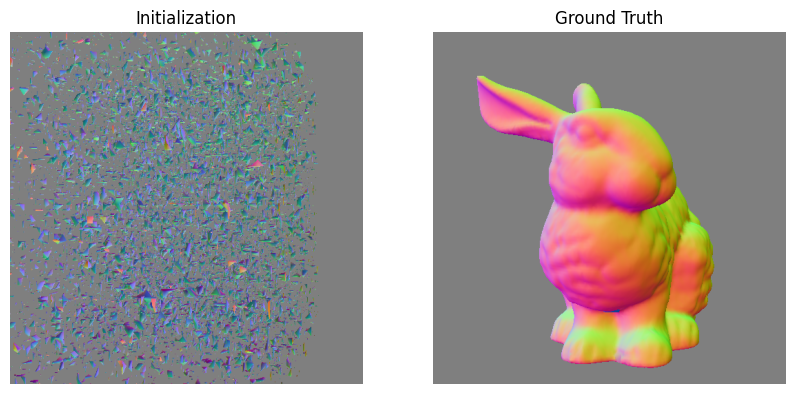

In [11]:
with torch.no_grad():
    mc_vertices, mc_faces, _, _ = c3d.ops.diff_marching_cubes(
        grid_vertices, voxels, sdf, iso=0.0)

print(f"vertices: {mc_vertices.shape}, faces: {mc_faces.shape}")
if mc_vertices.shape[0] > 0:
    init_mesh = kal.rep.SurfaceMesh(vertices=mc_vertices, faces=mc_faces)
    
    camera = render.get_rotate_camera(5)
    f, ax = plt.subplots(1, 2, figsize=(10, 5))
    output = render.render_mesh(glctx, init_mesh, camera, [512, 512], return_types=['normals'])
    ax[0].imshow(((output['normals'][0] + 1) / 2.).cpu().detach().numpy())
    ax[0].set_title("Initialization")
    ax[0].axis('off')
    
    output = render.render_mesh(glctx, gt_mesh, camera, [512, 512], return_types=['normals'])
    ax[1].imshow(((output['normals'][0] + 1) / 2.).cpu().detach().numpy())
    ax[1].set_title("Ground Truth")
    ax[1].axis('off')
    plt.show()


In [12]:
def lr_schedule(iter):
    return max(0.0, 10 ** (-(iter) * 0.0002)) # Exponential falloff from [1.0, 0.1] over 5k epochs.    
optimizer = torch.optim.Adam([sdf], lr=learning_rate)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda x: lr_schedule(x))


In [13]:
for it in tqdm.tqdm(range(iter)): 
    optimizer.zero_grad()
    # sample random camera poses
    cameras = render.get_random_camera_batch(batch, iter_res=train_res, device=device)
    
    # render gt mesh at sampled views
    target = render.render_mesh(glctx, gt_mesh, cameras, train_res, return_types = ["mask", "depth"])

    # mesh extraction
    mc_vertices, mc_faces, _, _ = c3d.ops.diff_marching_cubes(
        grid_vertices=grid_vertices, 
        voxels=voxels, 
        voxel_values=sdf, 
        iso=0.0
    )
    
    if mc_vertices.shape[0] == 0:
        continue
    
    extracted_mesh = kal.rep.SurfaceMesh(vertices=mc_vertices, faces=mc_faces.int())
    buffers = render.render_mesh(glctx, extracted_mesh, cameras, train_res, return_types = ["mask", "depth"])

    # reconstruction loss
    mask_loss = (buffers['mask'] - target['mask']).abs().mean() # mask loss
    depth_loss = (((((buffers['depth'] - (target['depth'])) * target['mask'])**2).sum(-1)+1e-8)).sqrt().mean() * 10 # depth loss

    total_loss = mask_loss + depth_loss
    total_loss.backward()
    optimizer.step()
    scheduler.step()
    
    if (it + 1) % 100 == 0: # save intermediate results every 100 iters
        print(f"Iter {it+1}/{iter}, Mask Loss: {mask_loss.item():.4f}, Depth Loss: {depth_loss.item():.4f}, Total Loss: {total_loss.item():.4f}")


 10%|█         | 103/1000 [00:03<00:29, 30.09it/s]

Iter 100/1000, Mask Loss: 0.0037, Depth Loss: 0.1137, Total Loss: 0.1174


 20%|██        | 203/1000 [00:06<00:26, 30.50it/s]

Iter 200/1000, Mask Loss: 0.0009, Depth Loss: 0.0496, Total Loss: 0.0505


 30%|███       | 303/1000 [00:10<00:22, 30.55it/s]

...

Iter 800/1000, Mask Loss: 0.0008, Depth Loss: 0.0309, Total Loss: 0.0317


 90%|█████████ | 903/1000 [00:29<00:03, 30.98it/s]

Iter 900/1000, Mask Loss: 0.0010, Depth Loss: 0.0329, Total Loss: 0.0338


100%|██████████| 1000/1000 [00:32<00:00, 30.60it/s]

Iter 1000/1000, Mask Loss: 0.0007, Depth Loss: 0.0330, Total Loss: 0.0337


In [14]:
with torch.no_grad():
    mc_vertices, mc_faces, _, _ = c3d.ops.diff_marching_cubes(
        grid_vertices=grid_vertices,
        voxels=voxels, 
        voxel_values=sdf, 
        iso=0.0
    )
    
final_mesh = kal.rep.SurfaceMesh(vertices=mc_vertices, faces=mc_faces)
print(f"Final vertices: {mc_vertices.shape}, Final faces: {mc_faces.shape}")


Final vertices: torch.Size([46558, 3]), Final faces: torch.Size([90796, 3])


In [15]:
# Evaluate using c3d chamfer distance
pc_prime, _ = kal.ops.mesh.sample_points(final_mesh.vertices.unsqueeze(0), final_mesh.faces, num_sampling_points)
pc_prime = pc_prime.squeeze(0)

chamfer_dist = c3d.ops.chamfer_distance(pc, pc_prime, squared=True)
print(f"Chamfer Distance: {chamfer_dist.item():.6f}")


Chamfer Distance: 0.012853


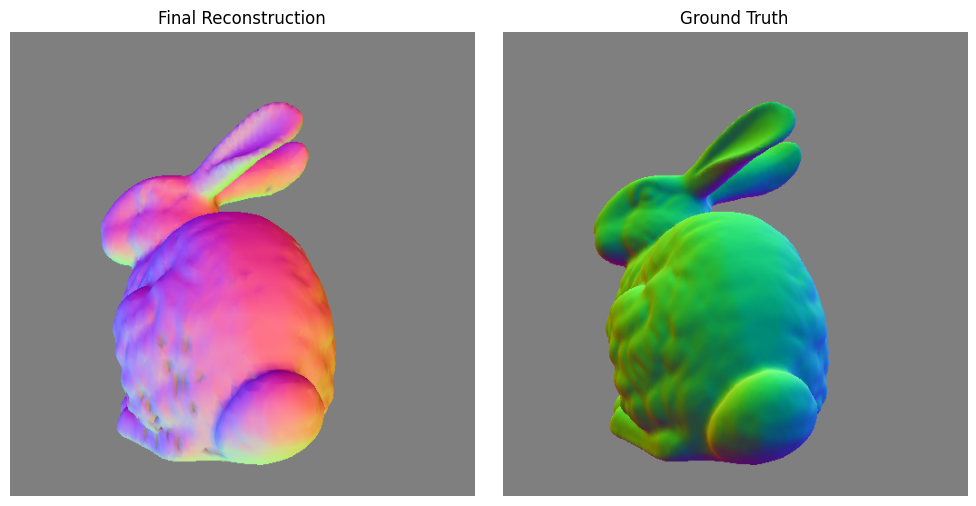

In [16]:



# Render the final oriented mesh using matplotlib (PNG) to keep notebook size minimal
camera = render.get_rotate_camera(0)
output_final = render.render_mesh(glctx, final_mesh, camera, [512, 512], return_types=['normals'])
img_final = ((output_final['normals'][0] + 1) / 2.).cpu().detach().numpy()

output_gt = render.render_mesh(glctx, gt_mesh, camera, [512, 512], return_types=['normals'])
img_gt = ((output_gt['normals'][0] + 1) / 2.).cpu().detach().numpy()

f, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img_final)
ax[0].set_title("Final Reconstruction")
ax[0].axis('off')

ax[1].imshow(img_gt)
ax[1].set_title("Ground Truth")
ax[1].axis('off')

plt.tight_layout()
plt.show()

# Rotate final mesh around the X-axis by 90 degrees to make Z-upward axis
angle = torch.tensor(np.pi / 2, device=device)
R_x = torch.tensor([
    [1.0, 0.0, 0.0],
    [0.0, torch.cos(angle), -torch.sin(angle)],
    [0.0, torch.sin(angle), torch.cos(angle)]
], device=device)

final_mesh.vertices = torch.matmul(final_mesh.vertices, R_x.T)
